# ResPlan HouseGAN++ Pretrain Inference Notebook


## 1) Setup & Paths


In [10]:
!pip install pytorch-fid torchinfo --quiet


### Optional: Download the dataset into `dataset/`


In [11]:
import os
from pathlib import Path

os.environ["KAGGLE_USERNAME"] = "jamesfu0424"
os.environ["KAGGLE_KEY"] = "KGAT_81c53df1cef4c387e4e95d41d565a6e8"

import kaggle

RESPLAN_DATASET = "resplan/resplan"
RESPLAN_TARGET_DIR = Path.cwd() / "dataset"
RESPLAN_TARGET_DIR.mkdir(parents=True, exist_ok=True)

kaggle.api.dataset_download_files(
    RESPLAN_DATASET,
    path=str(RESPLAN_TARGET_DIR),
    unzip=True,
    quiet=False,
)

print(f"Downloaded {RESPLAN_DATASET} into {RESPLAN_TARGET_DIR.resolve()}")


Dataset URL: https://www.kaggle.com/datasets/resplan/resplan


 55%|█████▌    | 54.0M/97.5M [00:00<00:00, 556MB/s]

100%|██████████| 97.5M/97.5M [00:00<00:00, 549MB/s]


Downloaded resplan/resplan into C:\Users\james\Desktop\11785_final\dataset


In [12]:
# ================================
# Basic Python libraries
# ================================
import os
import pickle
import random
import sys
from pathlib import Path

# ================================
# Core scientific stack
# ================================
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 110

# ================================
# Locate the ResPlan utility module
# ================================
PROJECT_ROOT = Path.cwd()
UTILITY_SEARCH_PATHS = [
    PROJECT_ROOT,
    PROJECT_ROOT / "dataset",
]
for candidate in UTILITY_SEARCH_PATHS:
    candidate_str = str(candidate.resolve())
    if candidate.exists() and candidate_str not in sys.path:
        sys.path.insert(0, candidate_str)

# ================================
# Import ResPlan utilities
# ================================
from resplan_utils import (
    CATEGORY_COLORS,
    normalize_keys,
    get_plan_width,
    get_geometries,
    centroid,
    geometry_to_mask,
    augment_geom,
    buffer_shrink_expand,
    buffer_expand_shrink,
    plot_plan,
    plan_to_graph,
    plot_plan_and_graph,
)

print("Working directory:", PROJECT_ROOT)
print("Utility search paths:", [str(p.resolve()) for p in UTILITY_SEARCH_PATHS if p.exists()])
print("Setup complete.")


Working directory: c:\Users\james\Desktop\11785_final
Utility search paths: ['C:\\Users\\james\\Desktop\\11785_final', 'C:\\Users\\james\\Desktop\\11785_final\\dataset']
Setup complete.


## 2) Download / Load Dataset


In [13]:
# Resolve a preview path first so the data-understanding cells can run
# before the full training config is introduced.
preview_candidates = [
    globals().get("DATA_PATH", ""),
    "/kaggle/input/datasets/resplan/resplan/ResPlan.pkl",
    str((Path.cwd() / "dataset" / "ResPlan.pkl").resolve()),
]
DATA_PATH = next((path for path in preview_candidates if path and os.path.exists(path)), "")
if not DATA_PATH:
    raise FileNotFoundError(
        "Could not find ResPlan.pkl. Download it into dataset/ or set DATA_PATH manually."
    )

with open(DATA_PATH, 'rb') as f:
    plans = pickle.load(f)

print(f'Loaded {len(plans)} plans from {DATA_PATH}')
example = plans[0]
print('Sample keys:', list(example.keys())[:20])

for p in plans:
    normalize_keys(p)


Loaded 17000 plans from C:\Users\james\Desktop\11785_final\dataset\ResPlan.pkl
Sample keys: ['balcony', 'bathroom', 'bedroom', 'door', 'garden', 'inner', 'parking', 'pool', 'stair', 'veranda', 'wall', 'window', 'front_door', 'unitType', 'id', 'kitchen', 'land', 'net_area', 'area', 'neighbor']


## 3) Understand the Data


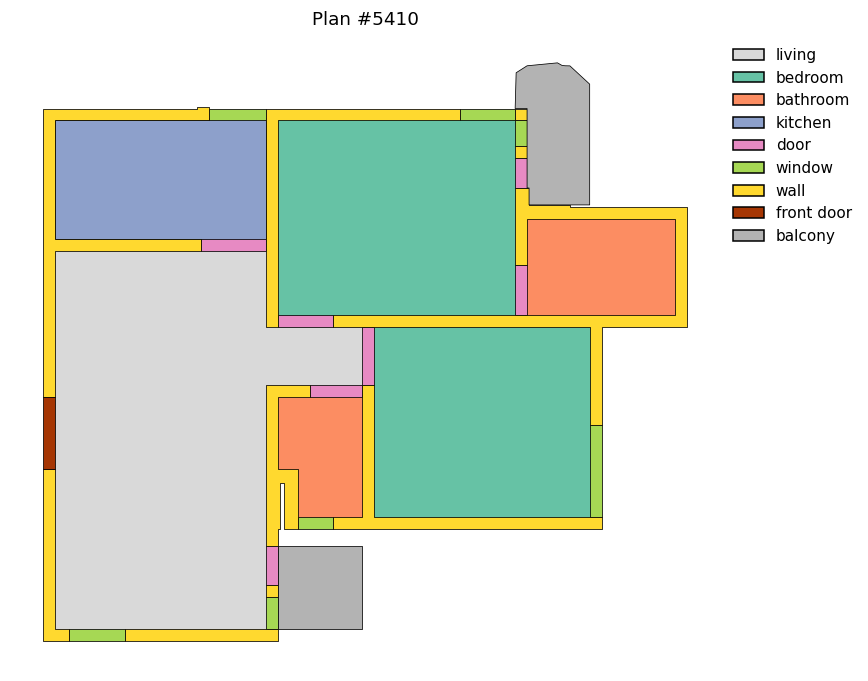

In [14]:
plan = plans[4]
ax = plot_plan(plan, title=f"Plan #{plan.get('id', 1)}")
plt.show()

### Inspect a raw plan dictionary


In [15]:
idx = random.randrange(len(plans))
plan = plans[idx]

print(f"Random plan index: {idx}")
print("Keys:", list(plan.keys()))
print("Wall width:", plan.get("wall_width"))
print("Available room categories:", [k for k in plan.keys() if plan.get(k) is not None and k != "graph"])


Random plan index: 6144
Keys: ['balcony', 'bathroom', 'bedroom', 'door', 'garden', 'inner', 'parking', 'pool', 'stair', 'veranda', 'wall', 'window', 'front_door', 'unitType', 'id', 'kitchen', 'land', 'net_area', 'area', 'neighbor', 'living', 'wall_depth', 'storage', 'graph']
Wall width: None
Available room categories: ['balcony', 'bathroom', 'bedroom', 'door', 'garden', 'inner', 'parking', 'pool', 'stair', 'veranda', 'wall', 'window', 'front_door', 'unitType', 'id', 'kitchen', 'land', 'net_area', 'area', 'neighbor', 'living', 'wall_depth', 'storage']


### Inspect the graph structure


In [16]:
from collections import Counter

# 假設你已有 plan
G = plan["graph"]

print("Graph type:", type(G))
print("num_nodes:", G.number_of_nodes())
print("num_edges:", G.number_of_edges())

# node type 統計
node_type_count = Counter([d.get("type", "unknown") for _, d in G.nodes(data=True)])
print("\nnode type count:", dict(node_type_count))

# edge type 統計
edge_type_count = Counter([d.get("type", "unknown") for _, _, d in G.edges(data=True)])
print("edge type count:", dict(edge_type_count))

print("\n--- first 10 nodes ---")
for i, (n, d) in enumerate(G.nodes(data=True)):

    print(n, "| type:", d.get("type"), "| area:", d.get("area"))

print("\n--- first 10 edges ---")
for i, (u, v, d) in enumerate(G.edges(data=True)):

    print((u, v), "| edge_type:", d.get("type"))

Graph type: <class 'networkx.classes.graph.Graph'>
num_nodes: 10
num_edges: 9

node type count: {'living': 1, 'kitchen': 1, 'bedroom': 2, 'bathroom': 2, 'balcony': 3, 'front_door': 1}
edge type count: {'direct': 1, 'adjacency': 3, 'via_door': 5}

--- first 10 nodes ---
living_0 | type: living | area: 11433.972748088632
kitchen_0 | type: kitchen | area: 3753.86789829366
bedroom_0 | type: bedroom | area: 7096.568611232117
bedroom_1 | type: bedroom | area: 5757.074240140743
bathroom_0 | type: bathroom | area: 1581.5625734104676
bathroom_1 | type: bathroom | area: 1608.766142807291
balcony_0 | type: balcony | area: 1649.7558523400587
balcony_1 | type: balcony | area: 1008.2094995756569
balcony_2 | type: balcony | area: 1063.0034941178114
front_door_0 | type: front_door | area: 106.8482893572029

--- first 10 edges ---
('living_0', 'front_door_0') | edge_type: direct
('living_0', 'kitchen_0') | edge_type: adjacency
('living_0', 'bedroom_0') | edge_type: adjacency
('living_0', 'bedroom_1') |

## 4) Dataset / Collate / Input Construction


### Convert a plan graph into room triples and node types


In [17]:
import re
import copy
import numpy as np

TYPE2ID = {
    "living": 1, "kitchen": 2, "bedroom": 3, "bathroom": 4,
    "balcony": 5, "front_door": 15, "door": 17, "interior_door": 17,
    "storage": 10, "unknown": 16,
}
NEED_DOOR_TYPES = {"adjacency", "via_door"}

def name_to_type(n):
    m = re.match(r"^(.+)_\d+$", str(n))
    return m.group(1) if m else "unknown"

def extract_with_door_nodes(G_raw):
    # ---- 0. deep copy + 去重 ----
    G = copy.deepcopy(G_raw)
    nodes_list = list(G.nodes(data=True))
    to_remove = []
    for i in range(len(nodes_list)):
        if nodes_list[i][0] in to_remove:
            continue
        gi = nodes_list[i][1].get("geometry")
        if gi is None:
            continue
        for j in range(i + 1, len(nodes_list)):
            if nodes_list[j][0] in to_remove:
                continue
            gj = nodes_list[j][1].get("geometry")
            if gj is None:
                continue
            if gi.equals(gj):
                to_remove.append(nodes_list[j][0])
    for node in to_remove:
        G.remove_node(node)

    # ---- 1. 只保留有邊的 node ----
    connected = set()
    for u, v in G.edges():
        connected.add(u)
        connected.add(v)
    original_nodes = [n for n in G.nodes() if n in connected]

    # ---- 2. 插入 interior_door node ----
    final_nodes = list(original_nodes)
    final_edges = []
    door_count = 0
    door_to_pair = {}

    for u, v, d in G.edges(data=True):
        if u not in connected or v not in connected:
            continue
        etype = d.get("type", "unknown")
        if etype in NEED_DOOR_TYPES:
            door_name = f"interior_door_{door_count}"
            door_count += 1
            final_nodes.append(door_name)
            final_edges.append((u, door_name))
            final_edges.append((door_name, v))
            door_to_pair[door_name] = (u, v)
        else:
            final_edges.append((u, v))

    # ---- 3. index mapping + room_type ----
    n2i = {n: i for i, n in enumerate(final_nodes)}
    room_type = [TYPE2ID.get(name_to_type(n), 16) for n in final_nodes]

    # ---- 4. pairwise triples ----
    pos = set()
    for u, v in final_edges:
        i, j = n2i[u], n2i[v]
        if i > j:
            i, j = j, i
        pos.add((i, j))

    N = len(final_nodes)
    triples = []
    for i in range(N):
        for j in range(i + 1, N):
            triples.append([i, 1 if (i, j) in pos else -1, j])

    return {
        "node_names": final_nodes,
        "room_type": room_type,
        "triples": triples,
        # "n_original": len(original_nodes),
        "n_doors_added": door_count,
        "n_dedup_removed": len(to_remove),
        "door_to_pair": door_to_pair,
    }

result = extract_with_door_nodes(plan["graph"])


print("去重移除:", result["n_dedup_removed"], "個 node")
print("node_names:", result["node_names"])
print("room_type:", result["room_type"])
print("N total:", len(result["node_names"]))
print("N doors added:", result["n_doors_added"])
print("door_to_pair:", result["door_to_pair"])
print("triples", result["triples"])



去重移除: 0 個 node
node_names: ['living_0', 'kitchen_0', 'bedroom_0', 'bedroom_1', 'bathroom_0', 'bathroom_1', 'balcony_0', 'balcony_1', 'balcony_2', 'front_door_0', 'interior_door_0', 'interior_door_1', 'interior_door_2', 'interior_door_3', 'interior_door_4', 'interior_door_5', 'interior_door_6', 'interior_door_7']
room_type: [1, 2, 3, 3, 4, 4, 5, 5, 5, 15, 17, 17, 17, 17, 17, 17, 17, 17]
N total: 18
N doors added: 8
door_to_pair: {'interior_door_0': ('living_0', 'kitchen_0'), 'interior_door_1': ('living_0', 'bedroom_0'), 'interior_door_2': ('living_0', 'bedroom_1'), 'interior_door_3': ('living_0', 'bathroom_0'), 'interior_door_4': ('living_0', 'balcony_2'), 'interior_door_5': ('bedroom_0', 'bathroom_1'), 'interior_door_6': ('bedroom_0', 'balcony_0'), 'interior_door_7': ('bedroom_1', 'balcony_1')}
triples [[0, -1, 1], [0, -1, 2], [0, -1, 3], [0, -1, 4], [0, -1, 5], [0, -1, 6], [0, -1, 7], [0, -1, 8], [0, 1, 9], [0, 1, 10], [0, 1, 11], [0, 1, 12], [0, 1, 13], [0, 1, 14], [0, -1, 15], [0, -

In [18]:
import numpy as np
import cv2
from shapely import affinity
from resplan_utils import normalize_keys, get_geometries, geometry_to_mask

def compute_plan_transform(plan, canvas_size=256, padding=4):
    categories = ("living", "kitchen", "bedroom", "bathroom", "balcony", "front_door", "door", "storage")
    plan = normalize_keys(plan)
    all_bounds = []
    for cat in categories:
        for g in get_geometries(plan.get(cat)):
            if not g.is_empty:
                all_bounds.append(g.bounds)
    if not all_bounds:
        return 0, 0, 1.0
    arr = np.array(all_bounds)
    minx, miny = arr[:, 0].min(), arr[:, 1].min()
    maxx, maxy = arr[:, 2].max(), arr[:, 3].max()
    range_x = maxx - minx
    range_y = maxy - miny
    max_range = max(range_x, range_y)
    if max_range < 1e-6:
        return -minx, -miny, 1.0
    usable = canvas_size - 2 * padding
    scale = usable / max_range
    shift_x = -minx * scale + padding + (usable - range_x * scale) / 2
    shift_y = -miny * scale + padding + (usable - range_y * scale) / 2
    return shift_x, shift_y, scale

def transform_geom(geom, shift_x, shift_y, scale):
    g = affinity.scale(geom, xfact=scale, yfact=scale, origin=(0, 0))
    g = affinity.translate(g, xoff=shift_x, yoff=shift_y)
    return g

def build_rms_masks_aligned(
    plan,
    G,
    node_names,
    room_type,
    door_to_pair,
    out_size=64,
    canvas_size=256,
    door_buffer=3.0,
):
    plan = normalize_keys(plan)

    # ---- 0. 計算座標轉換參數 ----
    shift_x, shift_y, scale = compute_plan_transform(plan, canvas_size=canvas_size)

    # ---- 1. 建立 room name → geometry 的 lookup（已轉換座標） ----
    geom_lookup = {}
    for cat in ("living", "kitchen", "bedroom", "bathroom", "balcony", "front_door", "storage"):
        geoms = get_geometries(plan.get(cat))
        for i, g in enumerate(geoms):
            geom_lookup[f"{cat}_{i}"] = transform_geom(g, shift_x, shift_y, scale)

    for n, d in G.nodes(data=True):
        g = d.get("geometry", None)
        if g is not None and n not in geom_lookup:
            geom_lookup[n] = transform_geom(g, shift_x, shift_y, scale)

    # ---- 2. 取出所有 door polygon（已轉換座標） ----
    door_polys_raw = get_geometries(plan.get("door"))
    door_polys = [transform_geom(dp, shift_x, shift_y, scale) for dp in door_polys_raw]

    # ---- 3. 配對 interior_door → door polygon ----
    door_geom_map = {}
    used_door_polys = set()

    for door_name, (room_a, room_b) in door_to_pair.items():
        geom_a = geom_lookup.get(room_a)
        geom_b = geom_lookup.get(room_b)
        if geom_a is None or geom_b is None:
            continue

        best_poly = None
        best_dist = float("inf")

        for idx, dp in enumerate(door_polys):
            if idx in used_door_polys:
                continue
            touches_a = dp.buffer(door_buffer).intersects(geom_a)
            touches_b = dp.buffer(door_buffer).intersects(geom_b)
            if touches_a and touches_b:
                from shapely.geometry import Point
                mid_x = (geom_a.centroid.x + geom_b.centroid.x) / 2
                mid_y = (geom_a.centroid.y + geom_b.centroid.y) / 2
                dist = dp.centroid.distance(Point(mid_x, mid_y))
                if dist < best_dist:
                    best_dist = dist
                    best_poly = idx

        if best_poly is not None:
            door_geom_map[door_name] = door_polys[best_poly]
            used_door_polys.add(best_poly)

    # ---- 4. 對每個 node 建 mask ----
    masks = []
    for name in node_names:
        geom = door_geom_map.get(name, None)
        if geom is None:
            geom = geom_lookup.get(name, None)

        if geom is None or geom.is_empty:
            masks.append(np.zeros((out_size, out_size), dtype=np.float32))
        else:
            m256 = geometry_to_mask(geom, shape=(canvas_size, canvas_size))
            m64 = cv2.resize(m256, (out_size, out_size), interpolation=cv2.INTER_NEAREST)
            masks.append(np.flipud((m64 > 0).astype(np.float32)))


    return np.stack(masks, axis=0) if masks else np.zeros((0, out_size, out_size), dtype=np.float32)

### Preview aligned room masks


rms_masks.shape: (18, 64, 64)


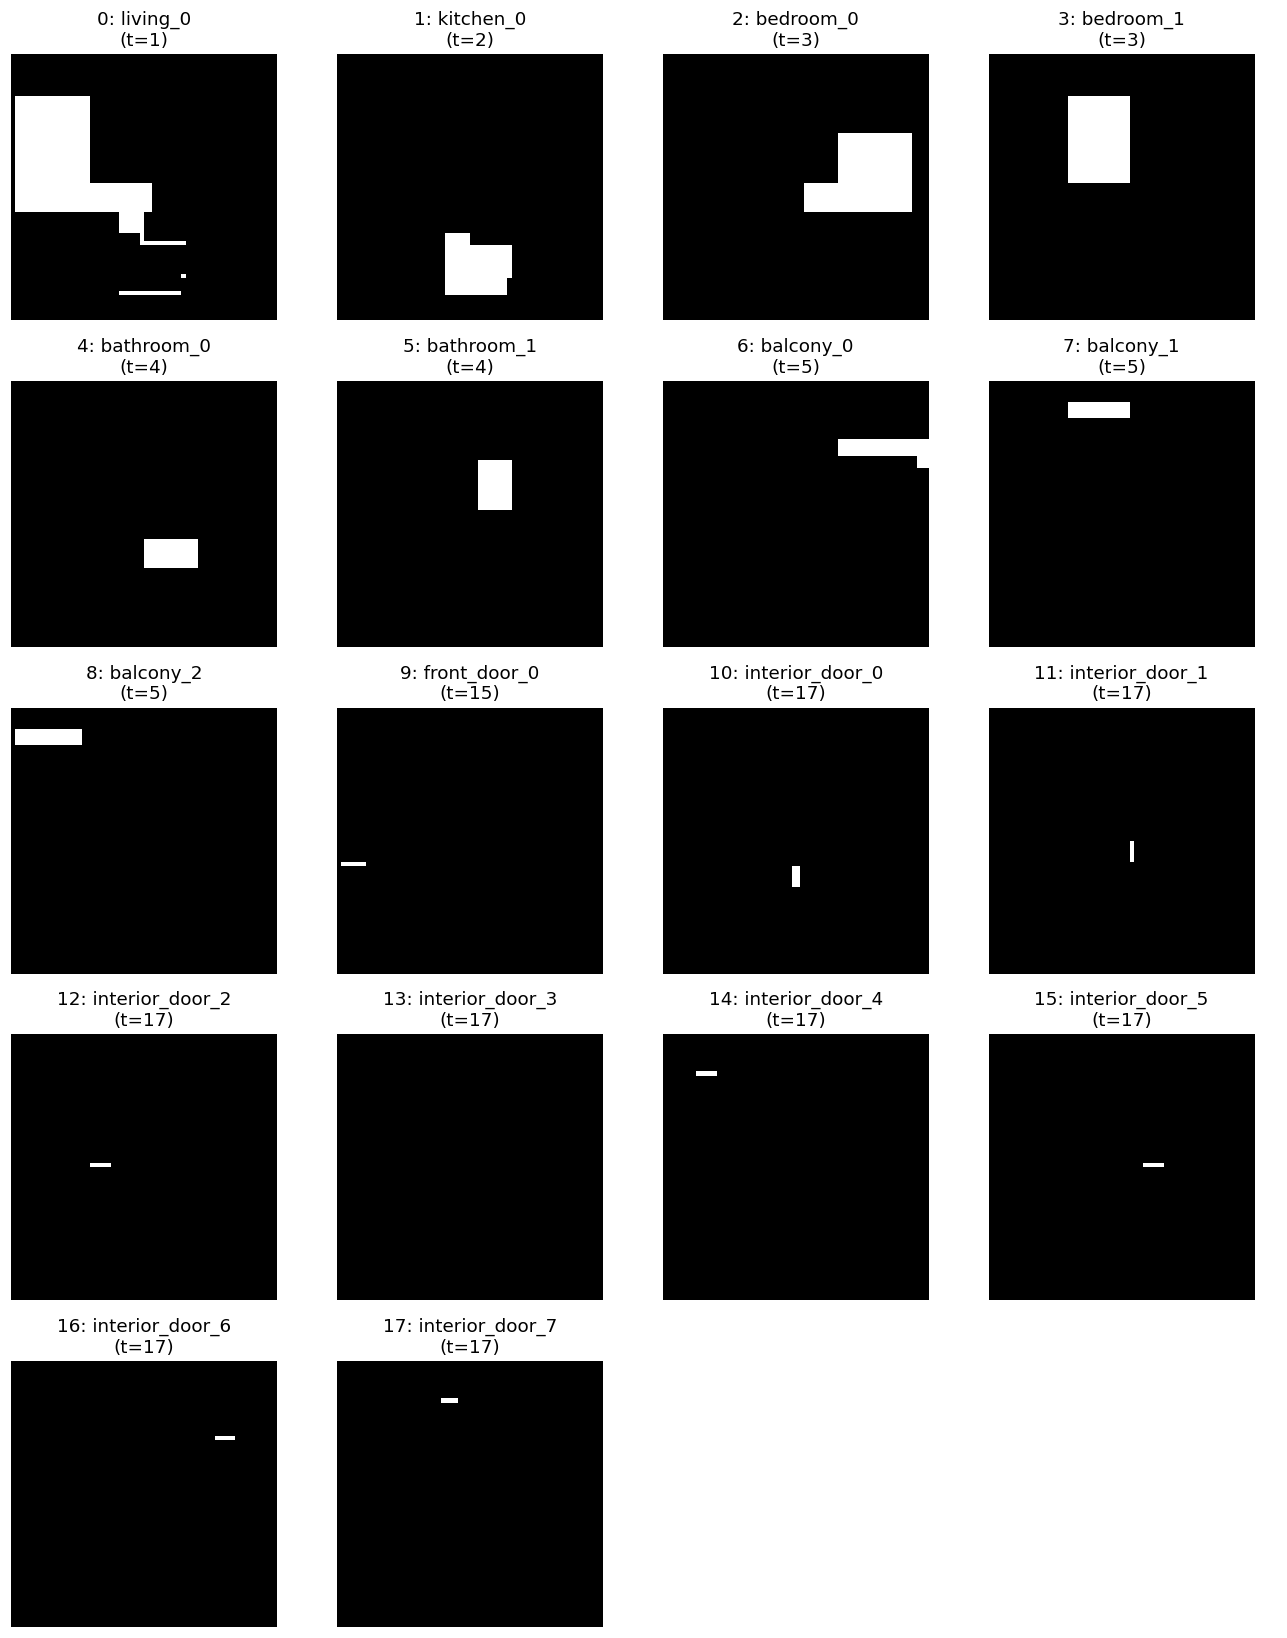

In [19]:
result = extract_with_door_nodes(G)

rms_masks = build_rms_masks_aligned(
    plan, G,
    result["node_names"],
    result["room_type"],
    result["door_to_pair"],
    out_size=64,
    
)

print("rms_masks.shape:", rms_masks.shape)

# 可視化
import matplotlib.pyplot as plt
K = rms_masks.shape[0]
cols = 4
rows = (K + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
axes = np.array(axes).reshape(-1)
for i in range(rows * cols):
    axes[i].axis("off")
    if i < K:
        axes[i].imshow(rms_masks[i], cmap="gray", vmin=0, vmax=1)
        axes[i].set_title(f"{i}: {result['node_names'][i]}\n(t={result['room_type'][i]})")
plt.tight_layout()
plt.show()

### Build sample / batch tensors


In [20]:
from torch.utils.data import Dataset, DataLoader
import torch


def one_hot_embedding(labels, num_classes=19):
    y = torch.eye(num_classes)
    return y[labels]


def plan_to_sample(plan, out_size=64):
    G_raw = plan["graph"]
    result = extract_with_door_nodes(G_raw)
    rms_masks = build_rms_masks_aligned(
        plan,
        G_raw,
        result["node_names"],
        result["room_type"],
        result["door_to_pair"],
        out_size=out_size,
    )

    room_type = np.array(result["room_type"])
    triples = np.array(result["triples"], dtype=np.int64)

    masks_tensor = torch.FloatTensor(rms_masks)
    masks_tensor = (masks_tensor - 0.5) / 0.5
    nodes_tensor = one_hot_embedding(torch.LongTensor(room_type))[:, 1:]
    edges_tensor = torch.LongTensor(triples)
    return masks_tensor, nodes_tensor, edges_tensor


class ResPlanDataset(Dataset):
    def __init__(self, plans, out_size=64):
        self.plans = plans
        self.out_size = out_size

    def __len__(self):
        return len(self.plans)

    def __getitem__(self, idx):
        return plan_to_sample(self.plans[idx], out_size=self.out_size)


def resplan_collate_fn(samples):
    all_mks, all_nds, all_eds = [], [], []
    all_nd_to_sample, all_ed_to_sample = [], []
    node_offset = 0

    for i, (mks, nds, eds) in enumerate(samples):
        N = nds.size(0)
        E = eds.size(0)
        all_mks.append(mks)
        all_nds.append(nds)

        eds = eds.clone()
        if E > 0:
            eds[:, 0] += node_offset
            eds[:, 2] += node_offset
            all_eds.append(eds)

        all_nd_to_sample.append(torch.LongTensor(N).fill_(i))
        all_ed_to_sample.append(torch.LongTensor(E).fill_(i))
        node_offset += N

    all_mks = torch.cat(all_mks, 0)
    all_nds = torch.cat(all_nds, 0)
    all_eds = torch.cat(all_eds, 0) if all_eds else torch.zeros(0, 3, dtype=torch.long)
    all_nd_to_sample = torch.cat(all_nd_to_sample)
    all_ed_to_sample = torch.cat(all_ed_to_sample)
    return all_mks, all_nds, all_eds, all_nd_to_sample, all_ed_to_sample


demo_samples = [plan_to_sample(plan, out_size=64) for plan in plans[:4]]
batch = resplan_collate_fn(demo_samples)
mks, nds, eds, nd_to_sample, ed_to_sample = batch

print("masks:", mks.shape, mks.dtype)
print("nodes:", nds.shape, nds.dtype)
print("edges:", eds.shape, eds.dtype)
print("nd_to_sample:", nd_to_sample.shape)
print("ed_to_sample:", ed_to_sample.shape)


masks: torch.Size([64, 64, 64]) torch.float32
nodes: torch.Size([64, 18]) torch.float32
edges: torch.Size([492, 3]) torch.int64
nd_to_sample: torch.Size([64])
ed_to_sample: torch.Size([492])


### Build the generator inputs used during inference


In [21]:
import torch
import numpy as np
import random

ROOM_CLASS = {
    "living_room": 1, "kitchen": 2, "bedroom": 3, "bathroom": 4,
    "balcony": 5, "entrance": 6, "dining room": 7, "study room": 8,
    "storage": 10, "front door": 15, "unknown": 16, "interior_door": 17
}

def selectNodesTypes(nd_to_sample, batch_size, nds):
    all_types = [ROOM_CLASS[k] - 1 for k in ROOM_CLASS]
    fixed_nodes = []
    shift = 0
    for k in range(batch_size):
        rooms = np.where(nd_to_sample == k)
        rooms_num = np.array(rooms).shape[-1]
        _types = np.where(nds[rooms] == 1)[1]
        _t = [t for t in all_types if random.uniform(0, 1) > 0.5]
        fixed_rooms = [r for r, _t_x in enumerate(_types) if _t_x in _t]
        fixed_nodes_state = torch.tensor(fixed_rooms, dtype=torch.long)
        if torch.cuda.is_available():
            fixed_nodes_state = fixed_nodes_state.cuda()
        fixed_nodes_state = fixed_nodes_state + shift
        fixed_nodes.append(fixed_nodes_state)
        shift += rooms_num
    fixed_nodes = torch.cat(fixed_nodes)
    bin_fixed_nodes = torch.zeros((nd_to_sample.shape[0], 1))
    bin_fixed_nodes[fixed_nodes.long()] = 1.0
    bin_fixed_nodes = bin_fixed_nodes.float()
    if torch.cuda.is_available():
        bin_fixed_nodes = bin_fixed_nodes.cuda()
    return fixed_nodes, bin_fixed_nodes

def fix_nodes(prev_mks, ind_fixed_nodes):
    if isinstance(prev_mks, torch.Tensor):
        given_masks = prev_mks.detach().clone()
    else:
        given_masks = torch.tensor(prev_mks, dtype=torch.float32)
    ind_not_fixed_nodes = torch.tensor(
        [k for k in range(given_masks.shape[0]) if k not in ind_fixed_nodes],
        dtype=torch.long
    )
    given_masks[ind_not_fixed_nodes] = -1.0
    given_masks = given_masks.unsqueeze(1)
    inds_masks = torch.zeros_like(given_masks)
    inds_masks[ind_not_fixed_nodes] = 0.0
    if isinstance(ind_fixed_nodes, torch.Tensor):
        inds_masks[ind_fixed_nodes.long()] = 1.0
    else:
        inds_masks[torch.tensor(ind_fixed_nodes, dtype=torch.long)] = 1.0
    given_masks = torch.cat([given_masks, inds_masks], 1)
    return given_masks

def _init_input(graph, prev_state=None, mask_size=64):
    given_nds, given_eds = graph
    given_nds = given_nds.float()
    if isinstance(given_eds, torch.Tensor):
        given_eds = given_eds.detach().clone().long()
    else:
        given_eds = torch.tensor(given_eds, dtype=torch.long)
    z = torch.randn(len(given_nds), 128, dtype=torch.float32)
    fixed_nodes = prev_state["fixed_nodes"]
    if prev_state["masks"] is None:
        prev_mks = torch.zeros((given_nds.shape[0], mask_size, mask_size), dtype=torch.float32) - 1.0
    else:
        prev_mks = prev_state["masks"]
        if isinstance(prev_mks, torch.Tensor):
            prev_mks = prev_mks.detach().clone()
        else:
            prev_mks = torch.tensor(prev_mks, dtype=torch.float32)
    if isinstance(fixed_nodes, torch.Tensor):
        fixed_nodes_t = fixed_nodes.detach().clone()
    else:
        fixed_nodes_t = torch.tensor(fixed_nodes, dtype=torch.long)
    given_masks_in = fix_nodes(prev_mks, fixed_nodes_t)
    if torch.cuda.is_available():
        z = z.cuda()
        given_masks_in = given_masks_in.cuda()
    return z, given_masks_in, given_nds, given_eds

In [22]:
mks, nds, eds, nd_to_sample, ed_to_sample = batch
device_preview = torch.device("cuda" if torch.cuda.is_available() else "cpu")

real_mks = mks.to(device_preview)
given_nds = nds.to(device_preview)
given_eds = eds.to(device_preview)
graph = [given_nds, given_eds]
batch_size = int(nd_to_sample.max().item()) + 1

ind_fixed_nodes, _ = selectNodesTypes(nd_to_sample.cpu().numpy(), batch_size, nds.cpu())
state = {"masks": real_mks, "fixed_nodes": ind_fixed_nodes}
z, given_masks_in, given_nds, given_eds = _init_input(graph, state)

print("z:", z.shape)
print("given_masks_in:", given_masks_in.shape)
print("given_nds:", given_nds.shape)
print("given_eds:", given_eds.shape)


z: torch.Size([64, 128])
given_masks_in: torch.Size([64, 2, 64, 64])
given_nds: torch.Size([64, 18])
given_eds: torch.Size([492, 3])


## 5) Config


In [23]:
import os
import pickle
import random
from pathlib import Path

PRETRAIN_CANDIDATES = [
    str((Path.cwd() / "pretrain" / "pretrained.pth").resolve()),
    "/kaggle/input/datasets/jamesfu0424/pretrain-pth/pretrained.pth",
]
default_pretrain_checkpoint = next((p for p in PRETRAIN_CANDIDATES if os.path.exists(p)), PRETRAIN_CANDIDATES[0])

existing_data_path = globals().get("DATA_PATH", "")
default_source = "custom" if existing_data_path else ("kaggle" if os.path.exists("/kaggle/input") else "local")
default_kaggle_root = "/kaggle/input/datasets/resplan/resplan"
default_local_root = str(Path.cwd() / "dataset")
default_output_dir = "/kaggle/working/outputs" if os.path.exists("/kaggle/working") else str(Path.cwd() / "outputs")
default_checkpoint_dir = "/kaggle/working/checkpoints" if os.path.exists("/kaggle/working") else str(Path.cwd() / "checkpoints")

cfg = {
    "data_source": default_source,
    "kaggle_dataset_root": default_kaggle_root,
    "local_dataset_root": default_local_root,
    "resplan_pkl_path": existing_data_path,
    "checkpoint_dir": default_checkpoint_dir,
    "output_dir": default_output_dir,
    "run_name": "houseganpp_pretrain_infer",
    "seed": 42,
    "batch_size": 1,
    "num_workers": 0,
    "pin_memory": False,
    "inference_checkpoint": default_pretrain_checkpoint,
    "num_infer_plans": 1,
    "fid_eval_samples": 80,
    "ged_eval_samples": 60,
}

class Opt:
    pass

opt = Opt()
for key, value in cfg.items():
    setattr(opt, key, value)


In [24]:
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def resolve_resplan_pkl_path(config):
    data_source = config["data_source"].lower()
    if data_source == "kaggle":
        root = config["kaggle_dataset_root"]
        pkl_path = os.path.join(root, "ResPlan.pkl")
    elif data_source == "local":
        root = config["local_dataset_root"]
        pkl_path = os.path.join(root, "ResPlan.pkl")
    elif data_source == "custom":
        pkl_path = config["resplan_pkl_path"]
        root = os.path.dirname(pkl_path) if pkl_path else ""
    else:
        raise ValueError(f"Unsupported data_source: {config['data_source']}")

    if not pkl_path:
        raise ValueError("resplan_pkl_path is empty. Set cfg['resplan_pkl_path'] when using custom data_source.")
    if not os.path.exists(pkl_path):
        raise FileNotFoundError(
            f"Resolved ResPlan.pkl not found at: {pkl_path}. "
            f"Check cfg['data_source'] and the corresponding dataset root/path settings."
        )
    return {
        "data_source": data_source,
        "dataset_root": root,
        "resplan_pkl_path": pkl_path,
    }


def load_plans_from_source(config):
    resolved = resolve_resplan_pkl_path(config)
    with open(resolved["resplan_pkl_path"], "rb") as f:
        runtime_plans = pickle.load(f)
    return resolved, runtime_plans


seed_everything(cfg["seed"])
resolved_data, plans_runtime = load_plans_from_source(cfg)
plans = plans_runtime

CHECKPOINT_DIR = cfg["checkpoint_dir"]
OUTPUT_DIR = cfg["output_dir"]
RUN_NAME = cfg["run_name"]
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Data source:", resolved_data["data_source"])
print("Dataset root:", resolved_data["dataset_root"])
print("ResPlan.pkl:", resolved_data["resplan_pkl_path"])
print("Loaded plans:", len(plans))
print("Inference checkpoint:", cfg["inference_checkpoint"])
print("Output dir:", OUTPUT_DIR)


Data source: custom
Dataset root: C:\Users\james\Desktop\11785_final\dataset
ResPlan.pkl: C:\Users\james\Desktop\11785_final\dataset\ResPlan.pkl
Loaded plans: 17000
Inference checkpoint: C:\Users\james\Desktop\11785_final\pretrain\pretrained.pth
Output dir: c:\Users\james\Desktop\11785_final\outputs


## 6) Model Definition


### HouseGAN++ Generator / Discriminator


In [25]:
import torch
import torch.nn as nn
import torch.nn.utils.spectral_norm as spectral_norm


def add_pool(x, nd_to_sample):
    dtype, device = x.dtype, x.device
    batch_size = int(torch.max(nd_to_sample).item()) + 1
    pooled_x = torch.zeros(batch_size, x.shape[-1], dtype=dtype, device=device)
    pool_to = nd_to_sample.view(-1, 1).expand_as(x).to(device)
    pooled_x = pooled_x.scatter_add(0, pool_to, x)
    return pooled_x


def compute_gradient_penalty(D, x, x_fake, given_y=None, given_w=None,
                             nd_to_sample=None, data_parallel=None, ed_to_sample=None):
    batch_size = int(torch.max(nd_to_sample).item()) + 1
    device = x.device
    u = torch.empty(x.shape[0], 1, 1, device=device).uniform_(0, 1)
    x_both = x.data * u + x_fake.data * (1 - u)
    x_both = x_both.requires_grad_(True)
    grad_outputs = torch.ones(batch_size, 1, device=device)
    out = D(x_both, given_y, given_w, nd_to_sample)
    grad = torch.autograd.grad(outputs=out, inputs=x_both, grad_outputs=grad_outputs,
                               retain_graph=True, create_graph=True, only_inputs=True)[0]
    gradient_penalty = ((grad.norm(2, 1).norm(2, 1) - 1) ** 2).mean()
    return gradient_penalty


def conv_block(in_channels, out_channels, k, s, p, act=None, upsample=False, spec_norm=False, batch_norm=False):
    block = []
    if upsample:
        layer = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=k, stride=s, padding=p, bias=True)
        block.append(spectral_norm(layer) if spec_norm else layer)
    else:
        layer = nn.Conv2d(in_channels, out_channels, kernel_size=k, stride=s, padding=p, bias=True)
        block.append(spectral_norm(layer) if spec_norm else layer)
    if batch_norm:
        block.append(nn.BatchNorm2d(out_channels))
    if act == "leaky":
        block.append(nn.LeakyReLU(0.1, inplace=True))
    elif act == "relu":
        block.append(nn.ReLU(inplace=True))
    elif act == "tanh":
        block.append(nn.Tanh())
    return block


class CMP(nn.Module):
    def __init__(self, in_channels):
        super(CMP, self).__init__()
        self.encoder = nn.Sequential(
            *conv_block(3 * in_channels, 2 * in_channels, 3, 1, 1, act="leaky"),
            *conv_block(2 * in_channels, 2 * in_channels, 3, 1, 1, act="leaky"),
            *conv_block(2 * in_channels, in_channels, 3, 1, 1, act="leaky"))

    def forward(self, feats, edges=None):
        dtype, device = feats.dtype, feats.device
        edges = edges.view(-1, 3)
        V = feats.size(0)
        pooled_v_pos = torch.zeros(V, feats.shape[-3], feats.shape[-1], feats.shape[-1], dtype=dtype, device=device)
        pooled_v_neg = torch.zeros(V, feats.shape[-3], feats.shape[-1], feats.shape[-1], dtype=dtype, device=device)
        pos_inds = torch.where(edges[:, 1] > 0)[0]
        pos_v_src = torch.cat([edges[pos_inds, 0], edges[pos_inds, 2]]).long()
        pos_v_dst = torch.cat([edges[pos_inds, 2], edges[pos_inds, 0]]).long()
        pos_vecs_src = feats[pos_v_src]
        pos_v_dst = pos_v_dst.view(-1, 1, 1, 1).expand_as(pos_vecs_src)
        pooled_v_pos.scatter_add_(0, pos_v_dst, pos_vecs_src)
        neg_inds = torch.where(edges[:, 1] < 0)[0]
        neg_v_src = torch.cat([edges[neg_inds, 0], edges[neg_inds, 2]]).long()
        neg_v_dst = torch.cat([edges[neg_inds, 2], edges[neg_inds, 0]]).long()
        neg_vecs_src = feats[neg_v_src]
        neg_v_dst = neg_v_dst.view(-1, 1, 1, 1).expand_as(neg_vecs_src)
        pooled_v_neg.scatter_add_(0, neg_v_dst, neg_vecs_src)
        enc_in = torch.cat([feats, pooled_v_pos, pooled_v_neg], 1)
        return self.encoder(enc_in)


class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.init_size = 32 // 4
        self.l1 = nn.Sequential(nn.Linear(146, 16 * self.init_size ** 2))
        self.upsample_1 = nn.Sequential(*conv_block(16, 16, 4, 2, 1, act="leaky", upsample=True))
        self.upsample_2 = nn.Sequential(*conv_block(16, 16, 4, 2, 1, act="leaky", upsample=True))
        self.upsample_3 = nn.Sequential(*conv_block(16, 16, 4, 2, 1, act="leaky", upsample=True))
        self.cmp_1 = CMP(16)
        self.cmp_2 = CMP(16)
        self.cmp_3 = CMP(16)
        self.cmp_4 = CMP(16)
        self.decoder = nn.Sequential(
            *conv_block(16, 256, 3, 1, 1, act="leaky"),
            *conv_block(256, 128, 3, 1, 1, act="leaky"),
            *conv_block(128, 1, 3, 1, 1, act="tanh"))

        self.l1_fixed = nn.Sequential(nn.Linear(1, 1 * self.init_size ** 2))
        self.enc_1 = nn.Sequential(
            *conv_block(2, 32, 3, 2, 1, act="leaky"),
            *conv_block(32, 32, 3, 2, 1, act="leaky"),
            *conv_block(32, 16, 3, 2, 1, act="leaky"))
        self.enc_2 = nn.Sequential(
            *conv_block(32, 32, 3, 1, 1, act="leaky"),
            *conv_block(32, 16, 3, 1, 1, act="leaky"))

    def forward(self, z, given_m=None, given_y=None, given_w=None, given_v=None):
        z = z.view(-1, 128)
        y = given_y.view(-1, 18)
        z = torch.cat([z, y], 1)
        x = self.l1(z)
        f = x.view(-1, 16, self.init_size, self.init_size)
        m = self.enc_1(given_m)
        f = torch.cat([f, m], 1)
        f = self.enc_2(f)
        x = self.cmp_1(f, given_w)
        x = self.upsample_1(x)
        x = self.cmp_2(x, given_w)
        x = self.upsample_2(x)
        x = self.cmp_3(x, given_w)
        x = self.upsample_3(x)
        x = self.cmp_4(x, given_w)
        x = self.decoder(x)
        x = x.view(-1, x.shape[2], x.shape[3])
        return x


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.encoder = nn.Sequential(
            *conv_block(9, 16, 3, 1, 1, act="leaky"),
            *conv_block(16, 16, 3, 1, 1, act="leaky"),
            *conv_block(16, 16, 3, 1, 1, act="leaky"),
            *conv_block(16, 16, 3, 1, 1, act="leaky"))
        self.l1 = nn.Sequential(nn.Linear(18, 8 * 64 ** 2))
        self.cmp_1 = CMP(16)
        self.downsample_1 = nn.Sequential(*conv_block(16, 16, 3, 2, 1, act="leaky"))
        self.cmp_2 = CMP(16)
        self.downsample_2 = nn.Sequential(*conv_block(16, 16, 3, 2, 1, act="leaky"))
        self.cmp_3 = CMP(16)
        self.downsample_3 = nn.Sequential(*conv_block(16, 16, 3, 2, 1, act="leaky"))
        self.cmp_4 = CMP(16)
        self.decoder = nn.Sequential(
            *conv_block(16, 256, 3, 2, 1, act="leaky"),
            *conv_block(256, 128, 3, 2, 1, act="leaky"),
            *conv_block(128, 128, 3, 2, 1, act="leaky"))
        self.fc_layer_global = nn.Sequential(nn.Linear(128, 1))

    def forward(self, x, given_y=None, given_w=None, nd_to_sample=None):
        x = x.view(-1, 1, 64, 64)
        y = self.l1(given_y)
        y = y.view(-1, 8, 64, 64)
        x = torch.cat([x, y], 1)
        x = self.encoder(x)
        x = self.cmp_1(x, given_w)
        x = self.downsample_1(x)
        x = self.cmp_2(x, given_w)
        x = self.downsample_2(x)
        x = self.cmp_3(x, given_w)
        x = self.downsample_3(x)
        x = self.cmp_4(x, given_w)
        x = self.decoder(x)
        x = x.view(-1, x.shape[1])
        x_g = add_pool(x, nd_to_sample)
        return self.fc_layer_global(x_g)


### Model Summary


In [26]:
from torchinfo import summary

device = "cuda" if torch.cuda.is_available() else "cpu"


def make_summary_graph_inputs(batch_size=2, image_size=64, noise_dim=128, cond_dim=18, device=device):
    z = torch.randn(batch_size, noise_dim, device=device)
    given_m = torch.randn(batch_size, 2, image_size, image_size, device=device)
    given_y = torch.randn(batch_size, cond_dim, device=device)
    given_w = torch.tensor([[idx, 1, idx] for idx in range(batch_size)], dtype=torch.long, device=device)
    nd_to_sample = torch.arange(batch_size, dtype=torch.long, device=device)
    return z, given_m, given_y, given_w, nd_to_sample


G = Generator().to(device)
D = Discriminator().to(device)

z, given_m, given_y, given_w, nd_to_sample = make_summary_graph_inputs(device=device)
real_x = torch.randn(z.size(0), 64, 64, device=device)

print(f"Using device: {device}")
print(f"Generator params: {sum(p.numel() for p in G.parameters() if p.requires_grad):,}")
print(f"Discriminator params: {sum(p.numel() for p in D.parameters() if p.requires_grad):,}")

generator_stats = summary(
    G,
    input_data=[z, given_m, given_y, given_w],
    depth=4,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    verbose=1,
)
print(generator_stats)

discriminator_stats = summary(
    D,
    input_data=[real_x, given_y, given_w, nd_to_sample],
    depth=4,
    col_names=["input_size", "output_size", "num_params", "trainable"],
    verbose=1,
)
print(discriminator_stats)


Using device: cpu
Generator params: 635,569
Discriminator params: 1,228,609
Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
Generator                                [2, 128]                  [2, 64, 64]               128                       True
├─Sequential: 1-1                        [2, 146]                  [2, 1024]                 --                        True
│    └─Linear: 2-1                       [2, 146]                  [2, 1024]                 150,528                   True
├─Sequential: 1-2                        [2, 2, 64, 64]            [2, 16, 8, 8]             --                        True
│    └─Conv2d: 2-2                       [2, 2, 64, 64]            [2, 32, 32, 32]           608                       True
│    └─LeakyReLU: 2-3                    [2, 32, 32, 32]           [2, 32, 32, 32]           --                        --
│    └─Conv2d: 2-4                       [2, 32, 32, 

## 7) Checkpoint and Inference Utilities


In [27]:
import matplotlib.pyplot as plt


def resolve_generator_checkpoint_path(selection):
    if selection and os.path.exists(str(selection)):
        return str(selection)
    raise FileNotFoundError(
        f"Could not resolve pretrained checkpoint from selection: {selection}. "
        f"Expected one of: {cfg['inference_checkpoint']} or another existing checkpoint path."
    )


def load_generator_from_checkpoint(generator, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = checkpoint.get("generator_state_dict", checkpoint) if isinstance(checkpoint, dict) else checkpoint
    generator.load_state_dict(state_dict, strict=True)
    generator.to(device)
    generator.eval()
    return checkpoint


def save_preview_grid(real_batch, fake_batch, out_path, max_items=6):
    real_np = real_batch.detach().cpu().numpy()
    fake_np = fake_batch.detach().cpu().numpy()
    n_items = min(max_items, real_np.shape[0])
    fig, axes = plt.subplots(2, n_items, figsize=(2.5 * n_items, 5))
    if n_items == 1:
        axes = np.array(axes).reshape(2, 1)
    for idx in range(n_items):
        axes[0, idx].imshow(real_np[idx], cmap="gray", vmin=-1, vmax=1)
        axes[0, idx].set_title(f"Real {idx}")
        axes[0, idx].axis("off")
        axes[1, idx].imshow(fake_np[idx], cmap="gray", vmin=-1, vmax=1)
        axes[1, idx].set_title(f"Gen {idx}")
        axes[1, idx].axis("off")
    axes[0, 0].set_ylabel("Real")
    axes[1, 0].set_ylabel("Gen")
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    plt.close(fig)
    return out_path


PREVIEW_DIR = os.path.join(OUTPUT_DIR, RUN_NAME, "pretrain_inference_previews")
os.makedirs(PREVIEW_DIR, exist_ok=True)
print("Preview dir:", PREVIEW_DIR)


Preview dir: c:\Users\james\Desktop\11785_final\outputs\houseganpp_pretrain_infer\pretrain_inference_previews


## 8) Inference


Inference checkpoint: C:\Users\james\Desktop\11785_final\pretrain\pretrained.pth
Saved preview: c:\Users\james\Desktop\11785_final\outputs\houseganpp_pretrain_infer\pretrain_inference_previews\pretrain_inference_preview.png
Generated masks shape: (20, 64, 64)


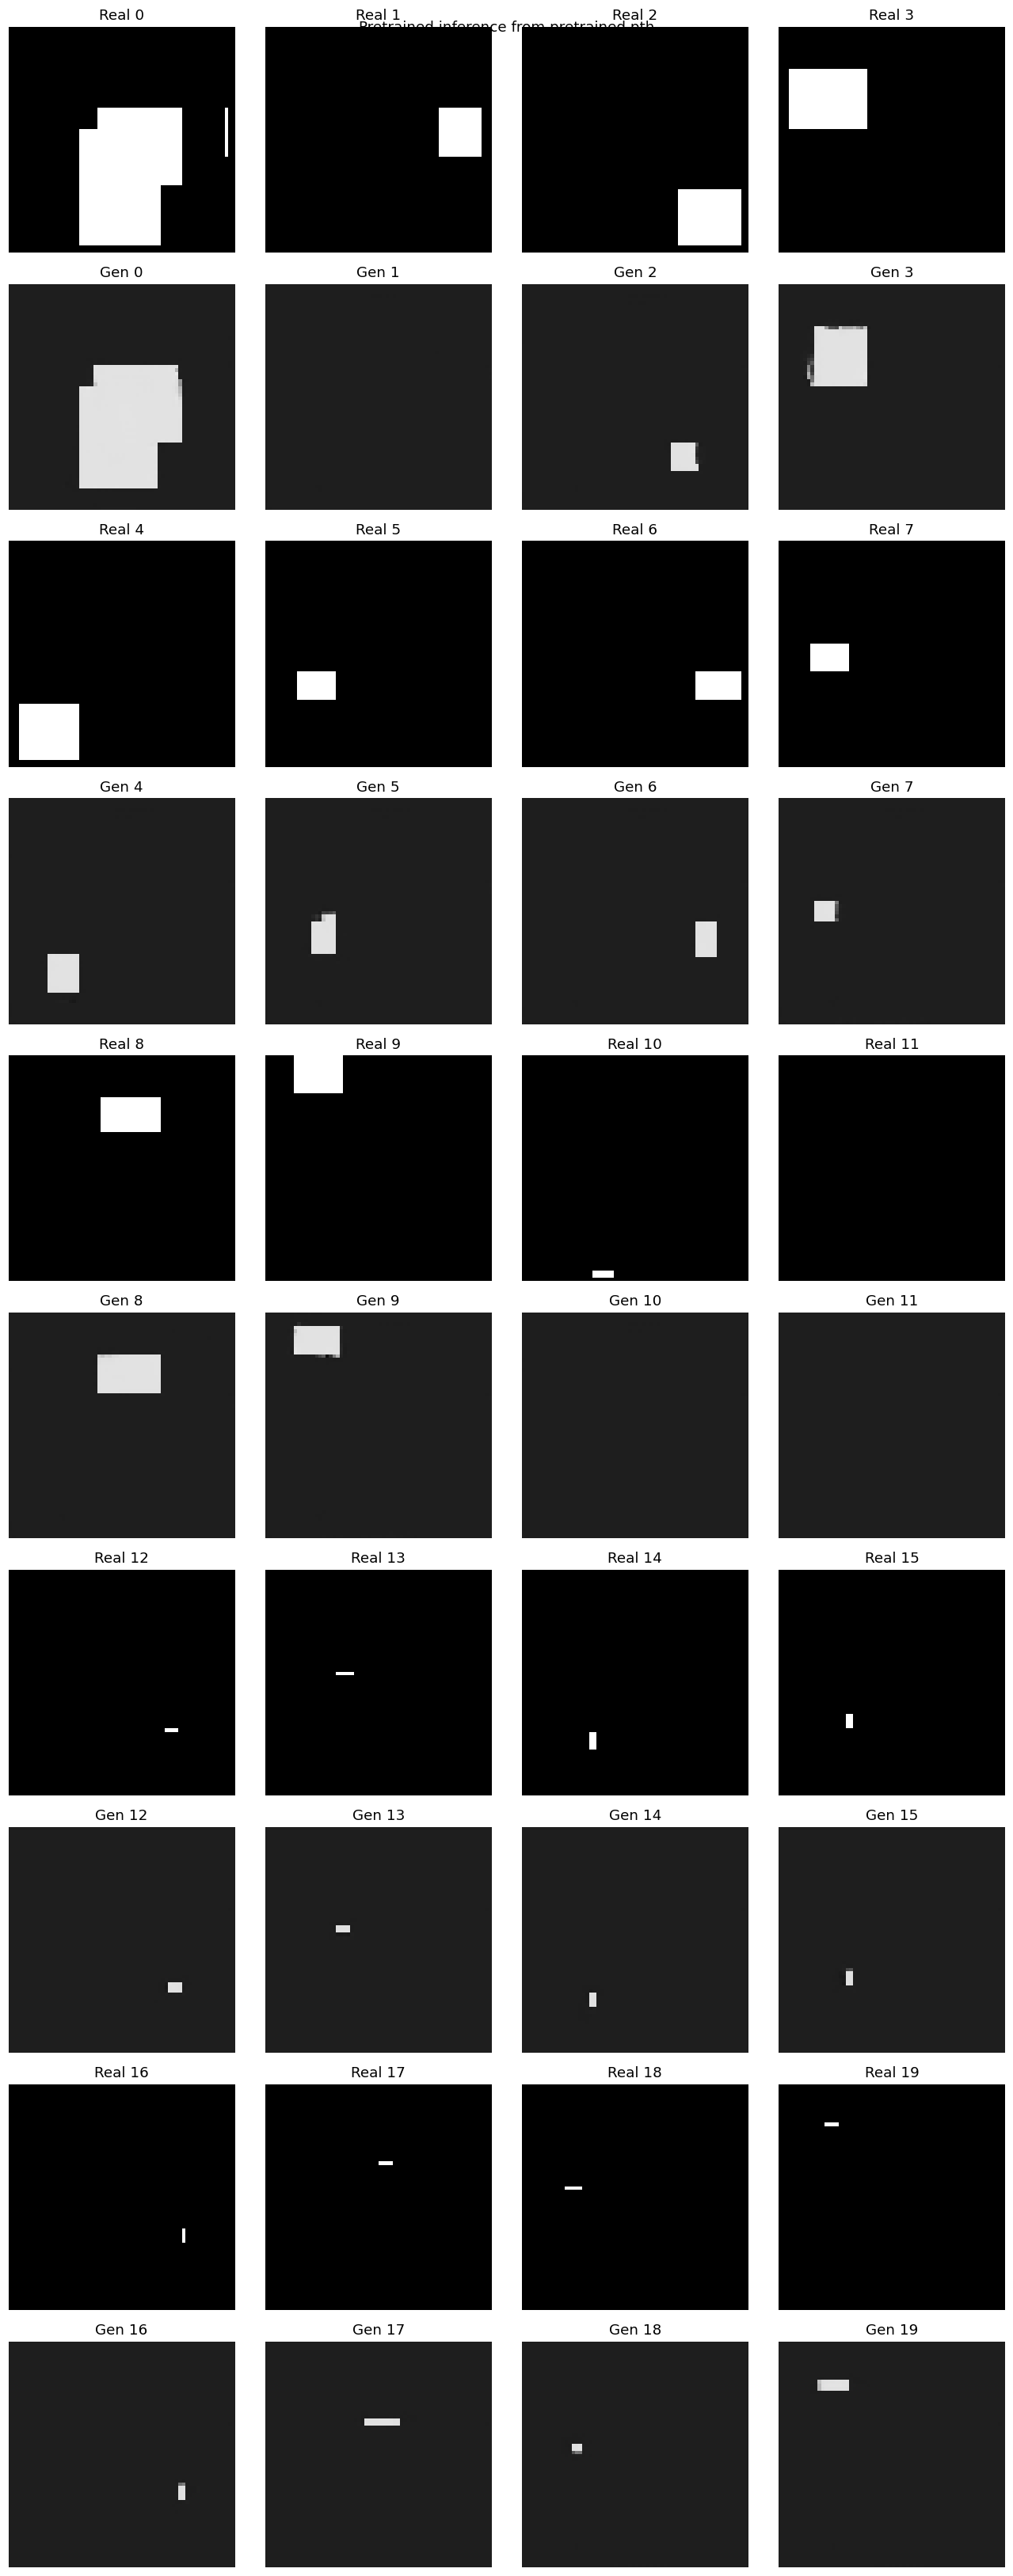

In [28]:
import os
import numpy as np
import matplotlib.pyplot as plt

selected_checkpoint = resolve_generator_checkpoint_path(cfg["inference_checkpoint"])
print("Inference checkpoint:", selected_checkpoint)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator_infer = Generator().to(device)
_ = load_generator_from_checkpoint(generator_infer, selected_checkpoint, device)

num_infer = cfg["num_infer_plans"]
plans_infer = plans[:num_infer]
samples_infer = [plan_to_sample(plan, out_size=64) for plan in plans_infer]
mks, nds, eds, nd_to_sample, ed_to_sample = resplan_collate_fn(samples_infer)

batch_size_infer = int(nd_to_sample.max().item()) + 1
real_mks = mks.to(device)
given_nds = nds.to(device)
given_eds = eds.to(device)
nd_to_sample = nd_to_sample.to(device)

graph_infer = [given_nds, given_eds]
ind_fixed_nodes, _ = selectNodesTypes(nd_to_sample.cpu().numpy(), batch_size_infer, nds.cpu())
state_infer = {"masks": real_mks, "fixed_nodes": ind_fixed_nodes}

z_infer, given_masks_in, given_nds, given_eds = _init_input(graph_infer, state_infer)
z_infer = z_infer.to(device)
given_masks_in = given_masks_in.to(device)
given_nds = given_nds.to(device)
given_eds = given_eds.to(device)

with torch.no_grad():
    gen_mks = generator_infer(
        z_infer,
        given_m=given_masks_in,
        given_y=given_nds,
        given_w=given_eds,
    )

preview_path = os.path.join(PREVIEW_DIR, "pretrain_inference_preview.png")
save_preview_grid(real_mks, gen_mks, preview_path, max_items=6)
print("Saved preview:", preview_path)

real_np = real_mks.detach().cpu().numpy()
gen_np = gen_mks.detach().cpu().numpy()
n_nodes = gen_np.shape[0]
print("Generated masks shape:", gen_np.shape)

cols = min(4, n_nodes)
rows = max(1, int(np.ceil(n_nodes / cols)))
fig, axes = plt.subplots(2 * rows, cols, figsize=(3 * cols, 3 * 2 * rows))
axes = np.array(axes).reshape(2 * rows, cols)

for idx in range(rows * cols):
    r_real = 2 * (idx // cols)
    r_fake = r_real + 1
    c = idx % cols
    axes[r_real, c].axis("off")
    axes[r_fake, c].axis("off")
    if idx < n_nodes:
        axes[r_real, c].imshow(real_np[idx], cmap="gray", vmin=-1, vmax=1)
        axes[r_real, c].set_title(f"Real {idx}")
        axes[r_fake, c].imshow(gen_np[idx], cmap="gray", vmin=-1, vmax=1)
        axes[r_fake, c].set_title(f"Gen {idx}")

plt.suptitle(f"Pretrained inference from {os.path.basename(selected_checkpoint)}")
plt.tight_layout()
plt.show()


## 9) Evaluation


### 9.1) FID Evaluation


In [29]:
import os
import numpy as np
import torch
import cv2
from PIL import Image, ImageDraw
from torch.utils.data import DataLoader
from pytorch_fid.fid_score import calculate_fid_given_paths

N_EVAL = cfg["fid_eval_samples"]
BATCH_SIZE_EVAL = 1
EVAL_CKPT = resolve_generator_checkpoint_path(cfg["inference_checkpoint"])
OUT_ROOT = os.path.join(OUTPUT_DIR, "pretrain_eval_compare")

MIN_NODES = 2
MAX_BOX_AREA = 0.90
THRESH = 0.0
USE_STRICT_EMPTY_SKIP = True

ID_COLOR_HEX = {
    1: '#EE4D4D', 2: '#C67C7B', 3: '#FFD274', 4: '#BEBEBE', 5: '#BFE3E8',
    6: '#7BA779', 7: '#E87A90', 8: '#FF8C69', 10: '#1F849B',
    15: '#727171', 16: '#785A67', 17: '#D3A2C7'
}
for k in range(1, 20):
    ID_COLOR_HEX.setdefault(k, '#808080')


def hex_to_rgb01(h):
    h = h.lstrip('#')
    return tuple(int(h[i:i+2], 16) / 255.0 for i in (0, 2, 4))


ID_COLOR_RGB01 = {k: hex_to_rgb01(v) for k, v in ID_COLOR_HEX.items()}


def draw_masks_overlay(masks, node_types, im_size=256):
    bg = Image.new("RGBA", (im_size, im_size), (255, 255, 255, 255))
    dr = ImageDraw.Draw(bg)
    for m, nd in zip(masks, node_types):
        m = np.array(m, copy=True)
        m[m > 0] = 255
        m[m <= 0] = 0
        m_lg = cv2.resize(m.astype(np.uint8), (im_size, im_size), interpolation=cv2.INTER_AREA)
        t = int(nd) + 1
        t = min(max(t, 1), 19)
        r, g, b = [int(x * 255) for x in ID_COLOR_RGB01[t]]
        m_pil = Image.fromarray(m_lg)
        dr.bitmap((0, 0), m_pil.convert('L'), fill=(r, g, b, 255))
        m_cv = m_lg[:, :, None].astype('uint8')
        _, thresh = cv2.threshold(m_cv, 127, 255, 0)
        contours, _ = cv2.findContours(thresh, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
        cnt = np.zeros((im_size, im_size, 3), dtype=np.uint8)
        if len(contours) > 0:
            cv2.drawContours(cnt, contours, -1, (255, 255, 255), 1)
        cnt_pil = Image.fromarray(cnt)
        dr.bitmap((0, 0), cnt_pil.convert('L'), fill=(0, 0, 0, 255))
    return bg.convert("RGB")


def mask_to_bb_strict(mask, thresh=0.0):
    arr = np.asarray(mask)
    ys, xs = np.where(arr > thresh)
    if ys.size == 0 or xs.size == 0:
        return None
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    return np.array([x0, y0, x1, y1], dtype=np.float32)


def draw_bbox_layout(bbs_norm, node_types, im_size=256):
    img = Image.new("RGB", (im_size, im_size), (0, 0, 0))
    dr = ImageDraw.Draw(img)
    for bb, nd in zip(bbs_norm, node_types):
        x0, y0, x1, y1 = bb
        x0, x1 = x0 * im_size, x1 * im_size
        y0, y1 = y0 * im_size, y1 * im_size
        if x1 <= x0 or y1 <= y0:
            continue
        t = int(nd) + 1
        t = min(max(t, 1), 19)
        color = tuple(int(c * 255) for c in ID_COLOR_RGB01[t])
        dr.rectangle([x0, y0, x1, y1], fill=color, outline=None)
    return img


def bb_area(bb):
    return max(0.0, bb[2] - bb[0]) * max(0.0, bb[3] - bb[1])


dirs = {
    "mask_real": f"{OUT_ROOT}/mask/real",
    "mask_fake": f"{OUT_ROOT}/mask/fake",
    "bbox_real": f"{OUT_ROOT}/bbox/real",
    "bbox_fake": f"{OUT_ROOT}/bbox/fake",
}
for d in dirs.values():
    os.makedirs(d, exist_ok=True)
    for fn in os.listdir(d):
        os.remove(os.path.join(d, fn))

n_plans = min(len(plans), max(N_EVAL * 5, 300))
eval_dataset = ResPlanDataset(plans[:n_plans], out_size=64)
eval_loader = DataLoader(
    eval_dataset,
    batch_size=BATCH_SIZE_EVAL,
    shuffle=False,
    collate_fn=resplan_collate_fn,
    num_workers=0,
)

device_eval = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gen_eval = Generator().to(device_eval)
_ = load_generator_from_checkpoint(gen_eval, EVAL_CKPT, device_eval)

saved = 0
skipped_node = 0
skipped_bbox = 0
skipped_area = 0

for batch in eval_loader:
    if saved >= N_EVAL:
        break

    mks, nds, eds, nd_to_sample, ed_to_sample = batch
    real_mks = mks.to(device_eval)
    given_nds = nds.to(device_eval)
    given_eds = eds.to(device_eval)
    batch_size_b = int(nd_to_sample.max().item()) + 1

    if real_mks.shape[0] < MIN_NODES:
        skipped_node += 1
        continue

    ind_fixed, _ = selectNodesTypes(nd_to_sample.cpu().numpy(), batch_size_b, nds.cpu())
    state = {"masks": real_mks, "fixed_nodes": ind_fixed}
    graph = [given_nds, given_eds]
    z, given_masks_in, given_nds2, given_eds2 = _init_input(graph, state)
    z = z.to(device_eval)
    given_masks_in = given_masks_in.to(device_eval)
    given_nds2 = given_nds2.to(device_eval)
    given_eds2 = given_eds2.to(device_eval)

    with torch.no_grad():
        gen_mks = gen_eval(z, given_m=given_masks_in, given_y=given_nds2, given_w=given_eds2)

    real_np = real_mks.detach().cpu().numpy()
    gen_np = gen_mks.detach().cpu().numpy()
    nd_np = given_nds2.detach().cpu().numpy()
    node_types = np.argmax(nd_np, axis=1)

    gen_bbs = []
    invalid = False
    H = gen_np.shape[-1]
    for j in range(gen_np.shape[0]):
        bb = mask_to_bb_strict(gen_np[j], thresh=THRESH)
        if bb is None and USE_STRICT_EMPTY_SKIP:
            invalid = True
            break
        if bb is None:
            bb = np.array([0, 0, 0, 0], dtype=np.float32)
        gen_bbs.append(bb)

    if invalid:
        skipped_bbox += 1
        continue

    gen_bbs = np.array(gen_bbs, dtype=np.float32)
    if any(bb_area(bb) / float(H * H) > MAX_BOX_AREA for bb in gen_bbs):
        skipped_area += 1
        continue

    gen_bbs_norm = gen_bbs / float(H)

    mask_real = draw_masks_overlay(real_np, node_types)
    mask_fake = draw_masks_overlay(gen_np, node_types)
    bbox_real = draw_bbox_layout(gen_bbs_norm, node_types)
    bbox_fake = draw_bbox_layout(gen_bbs_norm, node_types)

    stem = f"sample_{saved:04d}"
    mask_real.save(os.path.join(dirs["mask_real"], f"{stem}.png"))
    mask_fake.save(os.path.join(dirs["mask_fake"], f"{stem}.png"))
    bbox_real.save(os.path.join(dirs["bbox_real"], f"{stem}.png"))
    bbox_fake.save(os.path.join(dirs["bbox_fake"], f"{stem}.png"))
    saved += 1

print(f"saved={saved} skipped_node={skipped_node} skipped_bbox={skipped_bbox} skipped_area={skipped_area}")
if saved > 1:
    fid_mask = calculate_fid_given_paths([dirs["mask_real"], dirs["mask_fake"]], batch_size=8, device=device_eval, dims=2048)
    fid_bbox = calculate_fid_given_paths([dirs["bbox_real"], dirs["bbox_fake"]], batch_size=8, device=device_eval, dims=2048)
    print(f"FID mask-overlay : {fid_mask:.4f}")
    print(f"FID bbox-redraw  : {fid_bbox:.4f}")
else:
    print("Not enough valid samples for FID. Increase cfg['fid_eval_samples'] if needed.")


KeyboardInterrupt: 

### 9.2) GED Evaluation


In [ ]:
import numpy as np
import torch
import networkx as nx
from torch.utils.data import DataLoader

N_GED = cfg["ged_eval_samples"]
GED_UPPER_BOUND = 40
BBOX_THRESH = 0.0
OUT_SIZE = 64
EVAL_CKPT = resolve_generator_checkpoint_path(cfg["inference_checkpoint"])


def mask_to_bb(mask, thresh=0.0):
    arr = np.asarray(mask)
    ys, xs = np.where(arr > thresh)
    if ys.size == 0 or xs.size == 0:
        return None
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    return np.array([x0, y0, x1, y1], dtype=np.float32)


def is_adjacent(box_a, box_b, threshold=0.03):
    x0, y0, x1, y1 = box_a
    x2, y2, x3, y3 = box_b
    h1, h2 = x1 - x0, x3 - x2
    w1, w2 = y1 - y0, y3 - y2
    xc1, xc2 = (x0 + x1) / 2.0, (x2 + x3) / 2.0
    yc1, yc2 = (y0 + y1) / 2.0, (y2 + y3) / 2.0
    delta_x = np.abs(xc2 - xc1) - (h1 + h2) / 2.0
    delta_y = np.abs(yc2 - yc1) - (w1 + w2) / 2.0
    return max(delta_x, delta_y) < threshold


def retrieve_connections(nodes, room_bb):
    edges = []
    nodes = [x for x in nodes if x >= 0]
    room_bb = np.asarray(room_bb).reshape((-1, 4))
    for k, bb1 in enumerate(room_bb):
        for l, bb2 in enumerate(room_bb):
            if k > l and is_adjacent(bb1, bb2):
                edges.append((k, l))
    return nodes, edges


device_eval = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = Generator().to(device_eval)
_ = load_generator_from_checkpoint(generator, EVAL_CKPT, device_eval)

n_plans = min(len(plans), max(N_GED * 6, 200))
eval_dataset = ResPlanDataset(plans[:n_plans], out_size=OUT_SIZE)
eval_loader = DataLoader(
    eval_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=resplan_collate_fn,
    num_workers=0
)

ged_list = []
used = 0
skipped_bbox = 0

for batch in eval_loader:
    if used >= N_GED:
        break

    mks, nds, eds, nd_to_sample, ed_to_sample = batch
    real_mks = mks.to(device_eval)
    given_nds = nds.to(device_eval)
    given_eds = eds.to(device_eval)

    batch_size_b = int(nd_to_sample.max().item()) + 1
    ind_fixed, _ = selectNodesTypes(nd_to_sample.cpu().numpy(), batch_size_b, nds)
    state = {"masks": real_mks, "fixed_nodes": ind_fixed}
    graph = [given_nds, given_eds]

    z, given_masks_in, given_nds2, given_eds2 = _init_input(graph, state)
    z = z.to(device_eval)
    given_masks_in = given_masks_in.to(device_eval)
    given_nds2 = given_nds2.to(device_eval)
    given_eds2 = given_eds2.to(device_eval)

    with torch.no_grad():
        gen_mks = generator(z, given_m=given_masks_in, given_y=given_nds2, given_w=given_eds2)

    gen_np = gen_mks.detach().cpu().numpy()
    nd_np = given_nds2.detach().cpu().numpy()
    real_nodes = np.argmax(nd_np, axis=1)
    n_nodes = real_nodes.shape[0]
    H = gen_np.shape[-1]

    gen_bbs = []
    empty_bbox = False
    for j in range(n_nodes):
        bb = mask_to_bb(gen_np[j], thresh=BBOX_THRESH)
        if bb is None:
            empty_bbox = True
            break
        gen_bbs.append(bb)

    if empty_bbox:
        skipped_bbox += 1
        continue

    gen_bbs = np.array(gen_bbs, dtype=np.float32) / float(H)
    nodes_p, edges_p = retrieve_connections(real_nodes.tolist(), gen_bbs)

    G_pred = nx.Graph()
    for k, label in enumerate(nodes_p):
        G_pred.add_nodes_from([(k, {"label": int(label) + 1})])
    for (k, l) in edges_p:
        G_pred.add_edge(k, l)

    G_true = nx.Graph()
    for k, label in enumerate(real_nodes.tolist()):
        G_true.add_nodes_from([(k, {"label": int(label) + 1})])

    ed_np = eds.detach().cpu().numpy()
    for r in range(ed_np.shape[0]):
        src, rel, dst = int(ed_np[r, 0]), int(ed_np[r, 1]), int(ed_np[r, 2])
        if rel > 0:
            G_true.add_edge(src, dst)

    dists = [x for x in nx.optimize_graph_edit_distance(G_pred, G_true, upper_bound=GED_UPPER_BOUND)]
    ged = float(np.min(dists)) if len(dists) > 0 else float(GED_UPPER_BOUND)

    ged_list.append(ged)
    used += 1

print(f"[GED overall] used={used} skipped_bbox={skipped_bbox}")
if len(ged_list) > 0:
    print(f"[GED overall] mean={np.mean(ged_list):.4f}  std={np.std(ged_list):.4f}  min={np.min(ged_list):.4f}  max={np.max(ged_list):.4f}")
else:
    print("沒有成功湊到 GED 樣本，請調大 cfg['ged_eval_samples'] 或放寬過濾條件。")


## 10) Appendix / Reference


### Legacy GraphGPS Block (Reference Only)


In [ ]:
# GraphGPS generator/discriminator (Kaggle-ready)
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.nn.utils.spectral_norm as spectral_norm


def add_pool(x, nd_to_sample):
    dtype, device = x.dtype, x.device
    batch_size = int(torch.max(nd_to_sample).item()) + 1
    pooled_x = torch.zeros(batch_size, x.shape[-1], dtype=dtype, device=device)
    pool_to = nd_to_sample.view(-1, 1).expand_as(x).to(device)
    pooled_x = pooled_x.scatter_add(0, pool_to, x)
    return pooled_x


def compute_gradient_penalty(D, x, x_fake, given_y=None, given_w=None,
                             nd_to_sample=None, data_parallel=None, ed_to_sample=None):
    batch_size = int(torch.max(nd_to_sample).item()) + 1
    device = x.device
    u = torch.empty(x.shape[0], 1, 1, device=device).uniform_(0, 1)
    x_both = x.data * u + x_fake.data * (1 - u)
    x_both = x_both.requires_grad_(True)
    grad_outputs = torch.ones(batch_size, 1, device=device)
    out = D(x_both, given_y, given_w, nd_to_sample)
    grad = torch.autograd.grad(outputs=out, inputs=x_both, grad_outputs=grad_outputs,
                               retain_graph=True, create_graph=True, only_inputs=True)[0]
    gradient_penalty = ((grad.norm(2, 1).norm(2, 1) - 1) ** 2).mean()
    return gradient_penalty


def conv_block(in_channels, out_channels, k, s, p, act=None, upsample=False, spec_norm=False, batch_norm=False):
    block = []
    if upsample:
        layer = nn.ConvTranspose2d(in_channels, out_channels, kernel_size=k, stride=s, padding=p, bias=True)
        block.append(spectral_norm(layer) if spec_norm else layer)
    else:
        layer = nn.Conv2d(in_channels, out_channels, kernel_size=k, stride=s, padding=p, bias=True)
        block.append(spectral_norm(layer) if spec_norm else layer)
    if batch_norm:
        block.append(nn.BatchNorm2d(out_channels))
    if act == "leaky":
        block.append(nn.LeakyReLU(0.1, inplace=True))
    elif act == "relu":
        block.append(nn.ReLU(inplace=True))
    elif act == "tanh":
        block.append(nn.Tanh())
    return block


def _infer_graph_ids(num_nodes, edges, device):
    if edges is None or edges.numel() == 0:
        return torch.arange(num_nodes, device=device, dtype=torch.long)

    parent = torch.arange(num_nodes, device=device, dtype=torch.long)

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    for src, _, dst in edges.view(-1, 3).long():
        src_root = find(int(src.item()))
        dst_root = find(int(dst.item()))
        if src_root != dst_root:
            parent[dst_root] = src_root

    roots = torch.empty(num_nodes, device=device, dtype=torch.long)
    for idx in range(num_nodes):
        roots[idx] = find(idx)

    _, inverse = torch.unique(roots, return_inverse=True)
    return inverse


def _batched_attention(tokens, graph_ids, attn_module):
    num_graphs = int(graph_ids.max().item()) + 1
    counts = torch.bincount(graph_ids, minlength=num_graphs)
    max_nodes = int(counts.max().item())
    channels = tokens.size(-1)
    padded = tokens.new_zeros(num_graphs, max_nodes, channels)
    mask = torch.ones(num_graphs, max_nodes, dtype=torch.bool, device=tokens.device)

    for graph_idx in range(num_graphs):
        node_idx = torch.nonzero(graph_ids == graph_idx, as_tuple=False).flatten()
        n_nodes = node_idx.numel()
        padded[graph_idx, :n_nodes] = tokens[node_idx]
        mask[graph_idx, :n_nodes] = False

    attended, _ = attn_module(padded, padded, padded, key_padding_mask=mask, need_weights=False)

    out = tokens.new_empty(tokens.shape)
    for graph_idx in range(num_graphs):
        node_idx = torch.nonzero(graph_ids == graph_idx, as_tuple=False).flatten()
        n_nodes = node_idx.numel()
        out[node_idx] = attended[graph_idx, :n_nodes]
    return out


class CMP(nn.Module):
    def __init__(self, in_channels):
        super(CMP, self).__init__()
        self.encoder = nn.Sequential(
            *conv_block(3 * in_channels, 2 * in_channels, 3, 1, 1, act="leaky"),
            *conv_block(2 * in_channels, 2 * in_channels, 3, 1, 1, act="leaky"),
            *conv_block(2 * in_channels, in_channels, 3, 1, 1, act="leaky"))

    def forward(self, feats, edges=None):
        dtype, device = feats.dtype, feats.device
        if edges is None or edges.numel() == 0:
            zeros = torch.zeros_like(feats)
            return self.encoder(torch.cat([feats, zeros, zeros], 1))

        edges = edges.view(-1, 3)
        V = feats.size(0)
        C, H, W = feats.shape[-3:]
        pooled_v_pos = torch.zeros(V, C, H, W, dtype=dtype, device=device)
        pooled_v_neg = torch.zeros(V, C, H, W, dtype=dtype, device=device)

        pos_inds = torch.where(edges[:, 1] > 0)[0]
        if pos_inds.numel() > 0:
            pos_v_src = torch.cat([edges[pos_inds, 0], edges[pos_inds, 2]]).long()
            pos_v_dst = torch.cat([edges[pos_inds, 2], edges[pos_inds, 0]]).long()
            pos_vecs_src = feats[pos_v_src]
            pos_v_dst = pos_v_dst.view(-1, 1, 1, 1).expand_as(pos_vecs_src)
            pooled_v_pos.scatter_add_(0, pos_v_dst, pos_vecs_src)

        neg_inds = torch.where(edges[:, 1] < 0)[0]
        if neg_inds.numel() > 0:
            neg_v_src = torch.cat([edges[neg_inds, 0], edges[neg_inds, 2]]).long()
            neg_v_dst = torch.cat([edges[neg_inds, 2], edges[neg_inds, 0]]).long()
            neg_vecs_src = feats[neg_v_src]
            neg_v_dst = neg_v_dst.view(-1, 1, 1, 1).expand_as(neg_vecs_src)
            pooled_v_neg.scatter_add_(0, neg_v_dst, neg_vecs_src)

        enc_in = torch.cat([feats, pooled_v_pos, pooled_v_neg], 1)
        return self.encoder(enc_in)


class GraphGPSBlock(nn.Module):
    def __init__(self, channels, num_heads=4, mlp_ratio=4):
        super().__init__()
        self.local_gnn = CMP(channels)
        self.norm1 = nn.LayerNorm(channels)
        self.attn = nn.MultiheadAttention(channels, num_heads=num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(channels)
        hidden_dim = channels * mlp_ratio
        self.ffn = nn.Sequential(
            nn.Linear(channels, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, channels),
        )
        self.spatial_refine = nn.Sequential(
            *conv_block(channels, channels, 3, 1, 1, act="leaky"),
            *conv_block(channels, channels, 3, 1, 1, act="leaky"),
        )

    def forward(self, x, edges):
        x = x + self.local_gnn(x, edges)

        pooled = F.adaptive_avg_pool2d(x, output_size=1).flatten(1)
        graph_ids = _infer_graph_ids(x.size(0), edges, x.device)

        attn_in = self.norm1(pooled)
        attn_out = _batched_attention(attn_in, graph_ids, self.attn)
        tokens = pooled + attn_out

        ffn_in = self.norm2(tokens)
        tokens = tokens + self.ffn(ffn_in)

        delta = tokens - pooled
        x = x + delta.unsqueeze(-1).unsqueeze(-1)
        x = x + self.spatial_refine(x)
        return x


class Generator(nn.Module):
    def __init__(self, channels=16, noise_dim=128, cond_dim=18):
        super(Generator, self).__init__()
        self.init_size = 32 // 4
        self.channels = channels
        self.noise_dim = noise_dim
        self.cond_dim = cond_dim

        self.l1 = nn.Sequential(nn.Linear(noise_dim + cond_dim, channels * self.init_size ** 2))
        self.enc_1 = nn.Sequential(
            *conv_block(2, 32, 3, 2, 1, act="leaky"),
            *conv_block(32, 32, 3, 2, 1, act="leaky"),
            *conv_block(32, channels, 3, 2, 1, act="leaky"))
        self.enc_2 = nn.Sequential(
            *conv_block(2 * channels, 2 * channels, 3, 1, 1, act="leaky"),
            *conv_block(2 * channels, channels, 3, 1, 1, act="leaky"))

        self.gps_1 = GraphGPSBlock(channels)
        self.upsample_1 = nn.Sequential(*conv_block(channels, channels, 4, 2, 1, act="leaky", upsample=True))
        self.gps_2 = GraphGPSBlock(channels)
        self.upsample_2 = nn.Sequential(*conv_block(channels, channels, 4, 2, 1, act="leaky", upsample=True))
        self.gps_3 = GraphGPSBlock(channels)
        self.upsample_3 = nn.Sequential(*conv_block(channels, channels, 4, 2, 1, act="leaky", upsample=True))
        self.gps_4 = GraphGPSBlock(channels)

        self.decoder = nn.Sequential(
            *conv_block(channels, 256, 3, 1, 1, act="leaky"),
            *conv_block(256, 128, 3, 1, 1, act="leaky"),
            *conv_block(128, 1, 3, 1, 1, act="tanh"))

    def forward(self, z, given_m=None, given_y=None, given_w=None, given_v=None):
        z = z.view(-1, self.noise_dim)
        y = given_y.view(-1, self.cond_dim)
        z = torch.cat([z, y], 1)

        x = self.l1(z)
        f = x.view(-1, self.channels, self.init_size, self.init_size)

        m = self.enc_1(given_m)
        f = torch.cat([f, m], 1)
        f = self.enc_2(f)

        x = self.gps_1(f, given_w)
        x = self.upsample_1(x)
        x = self.gps_2(x, given_w)
        x = self.upsample_2(x)
        x = self.gps_3(x, given_w)
        x = self.upsample_3(x)
        x = self.gps_4(x, given_w)
        x = self.decoder(x)
        x = x.view(-1, x.shape[2], x.shape[3])
        return x


class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.encoder = nn.Sequential(
            *conv_block(9, 16, 3, 1, 1, act="leaky"),
            *conv_block(16, 16, 3, 1, 1, act="leaky"),
            *conv_block(16, 16, 3, 1, 1, act="leaky"),
            *conv_block(16, 16, 3, 1, 1, act="leaky"))
        self.l1 = nn.Sequential(nn.Linear(18, 8 * 64 ** 2))
        self.cmp_1 = CMP(16)
        self.downsample_1 = nn.Sequential(*conv_block(16, 16, 3, 2, 1, act="leaky"))
        self.cmp_2 = CMP(16)
        self.downsample_2 = nn.Sequential(*conv_block(16, 16, 3, 2, 1, act="leaky"))
        self.cmp_3 = CMP(16)
        self.downsample_3 = nn.Sequential(*conv_block(16, 16, 3, 2, 1, act="leaky"))
        self.cmp_4 = CMP(16)
        self.decoder = nn.Sequential(
            *conv_block(16, 256, 3, 2, 1, act="leaky"),
            *conv_block(256, 128, 3, 2, 1, act="leaky"),
            *conv_block(128, 128, 3, 2, 1, act="leaky"))
        self.fc_layer_global = nn.Sequential(nn.Linear(128, 1))

    def forward(self, x, given_y=None, given_w=None, nd_to_sample=None):
        x = x.view(-1, 1, 64, 64)
        y = self.l1(given_y)
        y = y.view(-1, 8, 64, 64)
        x = torch.cat([x, y], 1)
        x = self.encoder(x)
        x = self.cmp_1(x, given_w)
        x = self.downsample_1(x)
        x = self.cmp_2(x, given_w)
        x = self.downsample_2(x)
        x = self.cmp_3(x, given_w)
        x = self.downsample_3(x)
        x = self.cmp_4(x, given_w)
        x = self.decoder(x)
        x = x.view(-1, x.shape[1])
        x_g = add_pool(x, nd_to_sample)
        return self.fc_layer_global(x_g)



In [ ]:
# Legacy scratch cell kept for reference.


In [ ]:
# Legacy training loop kept out of the main pretrain-inference flow.


In [ ]:
# This notebook now visualizes real-vs-generated masks directly in the main inference cell above.
# Keep this cell empty unless you want to experiment with alternative plotting layouts.


In [ ]:
# import networkx as nx
# import matplotlib.pyplot as plt
# import matplotlib.patches as mpatches

# COLOR_BY_TYPE = {
#     1: "#EE4D4D",   # living
#     2: "#C67C7B",   # kitchen
#     3: "#FFD274",   # bedroom
#     4: "#BEBEBE",   # bathroom
#     5: "#BFE3E8",   # balcony
#     15: "#727171",  # front_door
#     17: "#D3A2C7",  # interior_door
#     16: "#785A67",  # unknown
# }

# TYPE_NAME = {
#     1: "living", 2: "kitchen", 3: "bedroom", 4: "bathroom",
#     5: "balcony", 15: "front_door", 17: "interior_door", 16: "unknown",
# }

# def visualize_triples(node_names, room_type, triples, title="Pairwise Graph"):
#     G = nx.Graph()

#     for i, name in enumerate(node_names):
#         G.add_node(i, label=name, type_id=room_type[i])

#     for i, rel, j in triples:
#         if rel == 1:
#             G.add_edge(i, j)

#     colors = [COLOR_BY_TYPE.get(room_type[i], "#000000") for i in range(len(node_names))]
#     labels = {i: f"{i}\n{node_names[i]}" for i in range(len(node_names))}
#     sizes = [800 if room_type[i] not in (15, 17) else 400 for i in range(len(node_names))]

#     fig, ax = plt.subplots(figsize=(10, 8))
#     pos = nx.spring_layout(G, seed=42, k=2.0)
#     nx.draw(G, pos, ax=ax,
#             node_color=colors, node_size=sizes,
#             labels=labels, font_size=7, font_weight="bold",
#             edge_color="#888888", width=2.0, with_labels=True)

#     # legend
#     seen = []
#     handles = []
#     for tid in room_type:
#         if tid not in seen:
#             seen.append(tid)
#             handles.append(mpatches.Patch(
#                 color=COLOR_BY_TYPE.get(tid, "#000"),
#                 label=f"{tid}: {TYPE_NAME.get(tid, '?')}"
#             ))
#     ax.legend(handles=handles, loc="upper left", frameon=True)
#     ax.set_title(title)
#     plt.tight_layout()
#     plt.show()

# # === 使用 ===
# visualize_triples(
#     result["node_names"],
#     result["room_type"],
#     result["triples"],
#     title=f"Plan #{plan.get('id', '?')} — Pairwise Graph (+1 edges only)"
# )

## Res-Ref) Geometry → mask examples

In [ ]:
# shape = (256, 256)  # target canvas HxW

# bed_mask  = geometry_to_mask(plan.get('bedroom'), shape=shape)
# bath_mask = geometry_to_mask(plan.get('bathroom'), shape=shape)
# kit_mask  = geometry_to_mask(plan.get('kitchen'), shape=shape)

# fig, axs = plt.subplots(1, 3, figsize=(20, 6))
# axs[0].imshow(bed_mask,); axs[0].set_title('Bedroom mask');  axs[0].axis('off')
# axs[1].imshow(bath_mask); axs[1].set_title('Bathroom mask'); axs[1].axis('off')
# axs[2].imshow(kit_mask); axs[2].set_title('Kitchen mask');  axs[2].axis('off')
# plt.tight_layout(); plt.show()

## Res-Ref) Simple augmentations (rotate / vertical flip / scale)

In [ ]:
# aug_deg  = 45       # rotate 90 degrees
# aug_flip = True      # vertical flip **
# aug_scale = 0.9      # scale down a bit
# canvas_size = 256

# aug_plan = dict(plan)  # shallow copy
# for key in ['living','bedroom','bathroom','kitchen','door','window','wall','front_door','balcony']:
#     if key in aug_plan and aug_plan[key] is not None:
#         aug_plan[key] = augment_geom(aug_plan[key], degree=aug_deg, flip_vertical=aug_flip, scale=aug_scale, size=canvas_size)

# ax = plot_plan(aug_plan, title=f'Augmented plan (deg={aug_deg}, flip={aug_flip}, scale={aug_scale})')
# plt.show()

## Res-Ref) Buffer helpers (shrink→expand / expand→shrink)
These are handy for morphological cleanup or filling tiny gaps.

In [ ]:
# if plan.get('living') is not None:
#     ww = float(plan.get('wall_width', 3.0) or 3.0)
#     cleaned = buffer_shrink_expand(plan['living'], ww/2)
#     filled  = buffer_expand_shrink(plan['living'], ww/2)

#     fig, axs = plt.subplots(1, 2, figsize=(8, 4))
#     plot_plan({'living': cleaned}, title='Shrink→Expand (cleanup)', ax=axs[0]); axs[0].set_axis_off()
#     plot_plan({'living': filled},  title='Expand→Shrink (fill gaps)', ax=axs[1]); axs[1].set_axis_off()
#     plt.tight_layout(); plt.show()

## Res-Ref) Plan → graph + overlay

In [ ]:
# ax = plot_plan_and_graph(plan, title=f'Graph overlay for plan #{idx}')
# plt.show()
# plan = plans[1]
# G = plan_to_graph(plan)
# print(f'Graph nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}')
# print("type(G):", type(G))

## Res-Ref) build a multi-channel mask tensor

In [ ]:
# def multi_mask(plan, keys=('living','bedroom','bathroom','kitchen'), size=(256,256)):
#     chans = []
#     for k in keys:
#         chans.append(geometry_to_mask(plan.get(k), shape=size) / 255.0)  # normalize to [0,1]
#     return np.stack(chans, axis=0)  # CxHxW

# mm = multi_mask(plan)
# print('Multi-mask shape (C,H,W):', mm.shape)

## Res-Ref) Batch export a few samples

In [ ]:
# out_dir = 'plan_pngs'
# os.makedirs(out_dir, exist_ok=True)

# for i in range(5):
#     j = random.randrange(len(plans))
#     ax = plot_plan_and_graph(plans[j], title=f'Plan {j}')
#     out_path = os.path.join(out_dir, f'plan_{j}.png')
#     plt.savefig(out_path, bbox_inches='tight', pad_inches=0, dpi=200)
#     plt.close()
# print('Saved example figures to:', out_dir)

## Reference: Rplan Data for Graph Training

In [ ]:
# import numpy as np
# from PIL import Image, ImageDraw

# def make_sequence(edges):
#     polys = []
#     if len(edges) == 0:
#         return [[]]

#     v_curr = tuple(edges[0][:2])
#     e_ind_curr = 0
#     e_visited = [0]
#     seq_tracker = [v_curr]
#     find_next = False

#     while len(e_visited) < len(edges):
#         if not find_next:
#             if v_curr == tuple(edges[e_ind_curr][2:]):
#                 v_curr = tuple(edges[e_ind_curr][:2])
#             else:
#                 v_curr = tuple(edges[e_ind_curr][2:])
#             find_next = True
#         else:
#             found = False
#             for k, e in enumerate(edges):
#                 if k in e_visited:
#                     continue
#                 if v_curr == tuple(e[:2]):
#                     v_curr = tuple(e[2:])
#                     e_ind_curr = k
#                     e_visited.append(k)
#                     found = True
#                     break
#                 elif v_curr == tuple(e[2:]):
#                     v_curr = tuple(e[:2])
#                     e_ind_curr = k
#                     e_visited.append(k)
#                     found = True
#                     break

#             if not found:
#                 # 找不到可接續邊，避免死循環
#                 break

#         if len(seq_tracker) > 0 and v_curr == seq_tracker[-1]:
#             polys.append(seq_tracker)
#             started_new = False
#             for k, e in enumerate(edges):
#                 if k not in e_visited:
#                     v_curr = tuple(e[:2])
#                     seq_tracker = [v_curr]
#                     find_next = False
#                     e_ind_curr = k
#                     e_visited.append(k)
#                     started_new = True
#                     break
#             if not started_new:
#                 break
#         else:
#             seq_tracker.append(v_curr)

#     if seq_tracker:
#         polys.append(seq_tracker)
#     return polys

# def build_graph_like_loader(rms_type, fp_eds, eds_to_rms, out_size=64):
#     triples = []
#     nodes = list(rms_type)

#     # pairwise triples (+1 / -1)
#     for k in range(len(nodes)):
#         for l in range(k + 1, len(nodes)):
#             is_adjacent = any((l in e_map) and (k in e_map) for e_map in eds_to_rms)
#             triples.append([k, 1 if is_adjacent else -1, l])

#     # 只取第一 owner，對齊原 loader 行為
#     eds_to_rms_tmp = [[e_map[0]] for e_map in eds_to_rms]

#     rms_masks = []
#     im_size = 256
#     fp_mk = np.zeros((out_size, out_size), dtype=np.float32)

#     for k in range(len(nodes)):
#         eds = [l for l, e_map in enumerate(eds_to_rms_tmp) if (k in e_map)]

#         rm_im = Image.new('L', (im_size, im_size))
#         dr = ImageDraw.Draw(rm_im)

#         edge_arr = np.array([fp_eds[l][:4] for l in eds], dtype=np.float32) if len(eds) > 0 else np.zeros((0,4), dtype=np.float32)
#         polys = make_sequence(edge_arr)
#         poly = polys[0] if len(polys) > 0 else []

#         poly = [(im_size * x, im_size * y) for x, y in poly]
#         if len(poly) >= 2:
#             dr.polygon(poly, fill='white')
#         else:
#             # 原版會 exit(0)，這裡改成保留空 mask
#             pass

#         rm_im = rm_im.resize((out_size, out_size))
#         rm_arr = np.array(rm_im, dtype=np.float32)
#         inds = np.where(rm_arr > 0)
#         rm_arr[inds] = 1.0
#         rms_masks.append(rm_arr)

#         if nodes[k] != 15 and nodes[k] != 17:
#             fp_mk[inds] = k + 1

#     # remove overlap for non-door rooms
#     for k in range(len(nodes)):
#         if nodes[k] != 15 and nodes[k] != 17:
#             rm_arr = np.zeros((out_size, out_size), dtype=np.float32)
#             inds = np.where(fp_mk == k + 1)
#             rm_arr[inds] = 1.0
#             rms_masks[k] = rm_arr

#     return np.array(nodes), np.array(triples, dtype=np.int64), np.array(rms_masks, dtype=np.float32)

In [ ]:


# d = {
#     "room_type": [3, 3, 2, 5, 4, 5, 1, 17, 17, 17, 17, 17, 17, 15],
#     "boxes": [
#         [51.0, 56.0, 96.0, 107.0], [78.0, 113.0, 124.0, 168.0], [159.0, 56.0, 205.0, 78.0],
#         [192.0, 84.0, 205.0, 107.0], [159.0, 84.0, 186.0, 107.0], [130.0, 183.0, 186.0, 200.0],
#         [102.0, 56.0, 186.0, 177.0], [195.0, 79.0, 205.0, 83.0], [114.0, 108.0, 126.0, 112.0],
#         [97.0, 96.0, 101.0, 105.0], [154.0, 66.0, 158.0, 76.0], [154.0, 96.0, 158.0, 108.0],
#         [137.0, 178.0, 179.0, 182.0], [137.0, 51.0, 149.0, 55.0]
#     ],
#     "edges": [
#         [51.0,56.0,51.0,107.0,3,0],[51.0,107.0,96.0,107.0,3,0],[96.0,107.0,96.0,56.0,3,1],[96.0,56.0,51.0,56.0,3,0],
#         [78.0,113.0,78.0,168.0,3,0],[78.0,168.0,124.0,168.0,3,0],[124.0,168.0,124.0,113.0,3,0],[124.0,113.0,78.0,113.0,3,1],
#         [159.0,56.0,159.0,78.0,2,1],[159.0,78.0,205.0,78.0,2,5],[205.0,78.0,205.0,56.0,2,0],[205.0,56.0,159.0,56.0,2,0],
#         [192.0,84.0,192.0,107.0,5,0],[192.0,107.0,205.0,107.0,5,0],[205.0,107.0,205.0,84.0,5,0],[205.0,84.0,192.0,84.0,5,2],
#         [159.0,84.0,159.0,107.0,4,1],[159.0,107.0,186.0,107.0,4,0],[186.0,107.0,186.0,84.0,4,0],[186.0,84.0,159.0,84.0,4,0],
#         [130.0,183.0,130.0,200.0,5,0],[130.0,200.0,186.0,200.0,5,0],[186.0,200.0,186.0,183.0,5,0],[186.0,183.0,130.0,183.0,5,1],
#         [102.0,56.0,102.0,107.0,1,3],[102.0,107.0,130.0,107.0,1,3],[130.0,107.0,130.0,177.0,1,0],[130.0,177.0,186.0,177.0,1,5],
#         [186.0,177.0,186.0,113.0,1,0],[186.0,113.0,153.0,113.0,1,0],[153.0,113.0,153.0,56.0,1,4],[153.0,56.0,102.0,56.0,1,0],
#         [195.0,79.0,195.0,83.0,17,0],[195.0,83.0,205.0,83.0,17,5],[205.0,83.0,205.0,79.0,17,0],[205.0,79.0,195.0,79.0,17,2],
#         [114.0,108.0,114.0,112.0,17,0],[114.0,112.0,126.0,112.0,17,3],[126.0,112.0,126.0,108.0,17,0],[126.0,108.0,114.0,108.0,17,1],
#         [97.0,96.0,97.0,105.0,17,3],[97.0,105.0,101.0,105.0,17,0],[101.0,105.0,101.0,96.0,17,1],[101.0,96.0,97.0,96.0,17,0],
#         [154.0,66.0,154.0,76.0,17,1],[154.0,76.0,158.0,76.0,17,0],[158.0,76.0,158.0,66.0,17,2],[158.0,66.0,154.0,66.0,17,0],
#         [154.0,96.0,154.0,108.0,17,1],[154.0,108.0,158.0,108.0,17,0],[158.0,108.0,158.0,96.0,17,4],[158.0,96.0,154.0,96.0,17,0],
#         [137.0,178.0,137.0,182.0,17,0],[137.0,182.0,179.0,182.0,17,5],[179.0,182.0,179.0,178.0,17,0],[179.0,178.0,137.0,178.0,17,1],
#         [137.0,51.0,137.0,55.0,15,0],[137.0,55.0,149.0,55.0,15,1],[149.0,55.0,149.0,51.0,15,0],[149.0,51.0,137.0,51.0,15,0]
#     ],
#     "ed_rm": [
#         [0],[0],[0,6],[0],[1],[1],[1],[1,6],[2,6],[2,3],[2],[2],[3],[3],[3],[3,2],[4,6],[4],[4],[4],[5],[5],[5],[5,6],
#         [6,0],[6,1],[6],[6,5],[6],[6],[6,4],[6],[7],[7,3],[7],[7,2],[8],[8,1],[8],[8,6],[9,0],[9],[9,6],[9],[10,6],[10],
#         [10,2],[10],[11,6],[11],[11,4],[11],[12],[12,5],[12],[12,6],[13],[13,6],[13],[13]
#     ]
# }
# # d = {... 你的 JSON ...}

# import numpy as np

# # simulate reader preprocessing
# rms_type = d["room_type"]
# rms_bbs = np.asarray(d["boxes"], dtype=np.float32) / 256.0
# fp_eds  = np.asarray(d["edges"], dtype=np.float32) / 256.0
# fp_eds  = fp_eds[:, :4]
# eds_to_rms = d["ed_rm"]

# tl = np.min(rms_bbs[:, :2], axis=0)
# br = np.max(rms_bbs[:, 2:], axis=0)
# shift = (tl + br) / 2.0 - 0.5
# rms_bbs[:, :2] -= shift
# rms_bbs[:, 2:] -= shift
# fp_eds[:, :2]  -= shift
# fp_eds[:, 2:]  -= shift

# # run
# nodes, triples, rms_masks = build_graph_like_loader(
#     rms_type, fp_eds, eds_to_rms, out_size=64
# )

# print("nodes.shape    :", nodes.shape)
# print("triples.shape  :", triples.shape)
# print("rms_masks.shape:", rms_masks.shape)

# rel = triples[:, 1]
# print("count(+1):", int((rel == 1).sum()))
# print("count(-1):", int((rel == -1).sum()))

# print("nodes:", nodes)
# print("triples:", triples)
# print("rms_masks:", rms_masks.tolist())